# 04 — Redes Convolucionales 1D (Conv1D)
Input `(N, V_in, 23)`. Conv1D extrae patrones locales en la dimensión temporal.
Catálogo activo: **conv_s** (Conv1D + GlobalAvgPool). Descomentar `[EXTENDER]` para más variantes.

> Nota: Conv1D requiere V_in ≥ kernel_size (3). Para V_in=5 funciona correctamente.

https://github.com/Romequinco/TAREA_REDES_NEURONALES

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, yfinance as yf
import tensorflow as tf

warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_mae_matrix, build_results_df, best_per_window)

In [ ]:
# ── HIPERPARÁMETROS ───────────────────────────────────────────
EPOCHS     = 300
BATCH_SIZE = 64
QUICK_MODE = False
if QUICK_MODE: EPOCHS = 50

precios = yf.download(TICKERS, start='1960-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}  |  EPOCHS={EPOCHS}')

Retornos: (16195, 23)  |  EPOCHS=150


## Individualizando

Existen **16 posibles combinaciones** de tamaños de ventanas de entrada-salida. Estas combinaciones se obtienen al cruzar las ventanas de entrada (`V_in`) con las ventanas de salida (`V_out`).

Las combinaciones consideradas son:

| Nº | `V_in` días | `V_out` días |
|---:|------------:|-------------:|
| 1  | 5  | 1  |
| 2  | 5  | 5  |
| 3  | 5  | 30 |
| 4  | 5  | 90 |
| 5  | 10 | 1  |
| 6  | 10 | 5  |
| 7  | 10 | 30 |
| 8  | 10 | 90 |
| 9  | 30 | 1  |
| 10 | 30 | 5  |
| 11 | 30 | 30 |
| 12 | 30 | 90 |
| 13 | 90 | 1  |
| 14 | 90 | 5  |
| 15 | 90 | 30 |
| 16 | 90 | 90 |

Se entrenará **un modelo para cada combinación de ventanas**, con el objetivo de comparar su rendimiento y determinar cuál de ellas ofrece la mejor opción.

# Modelo 1

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_1 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_1.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_1 = model_1.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_1)

# Evaluación
result = {
    'train': eval_mae(model_1, X_tr, y_tr),
    'val':   eval_mae(model_1, X_v, y_v),
    'test':  eval_mae(model_1, X_ts, y_ts),
    'params': model_1.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_1.history["loss"])}'
)


Entrenamiento terminado.
conv_s | in= 5 out= 1 | train=0.0128 val=0.0130 test=0.0225 ep=150


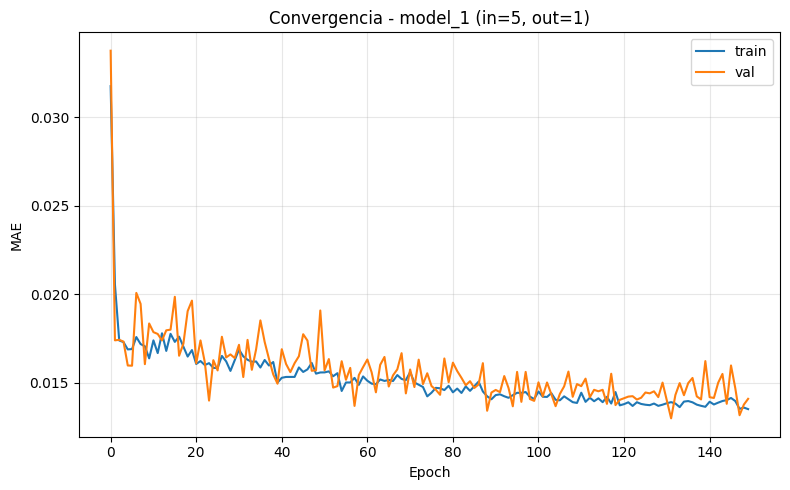

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist_1.history['loss'], label='train')
plt.plot(hist_1.history['val_loss'], label='val')

plt.title(f'Convergencia - model_1 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train      val     test  params  ep
conv_s     5      5 0.012792 0.012985 0.022543    5975 150


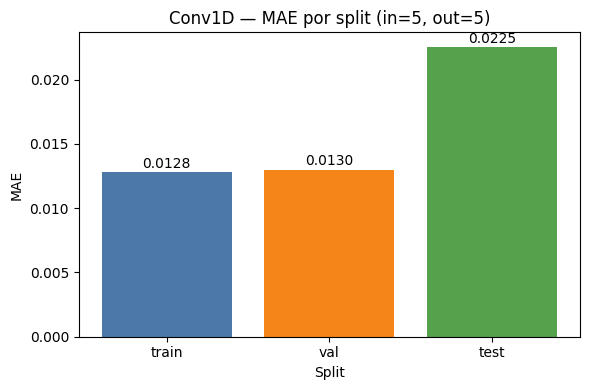

In [7]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_1.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 2

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_2 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_2.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_2 = model_2.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_2)

# Evaluación
result = {
    'train': eval_mae(model_2, X_tr, y_tr),
    'val':   eval_mae(model_2, X_v, y_v),
    'test':  eval_mae(model_2, X_ts, y_ts),
    'params': model_2.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_2.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out= 5 | train=0.0069 val=0.0069 test=0.0100 ep=150


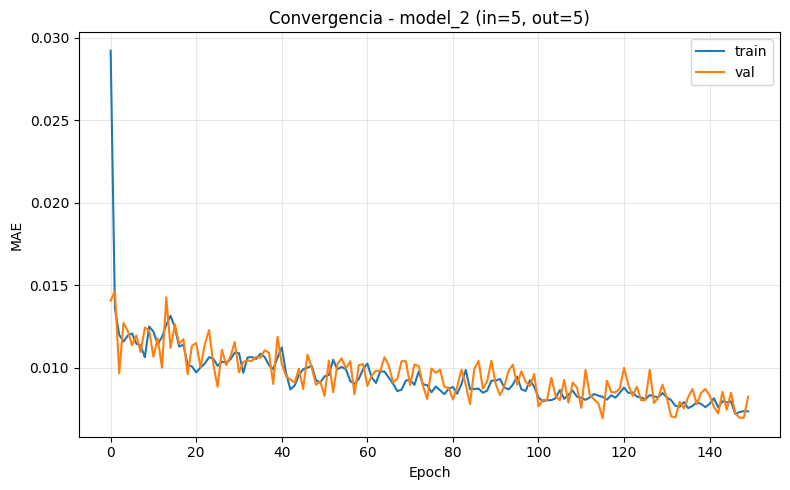

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(hist_2.history['loss'], label='train')
plt.plot(hist_2.history['val_loss'], label='val')

plt.title(f'Convergencia - model_2 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s     5      5 0.006907 0.006935 0.009959    5975 150


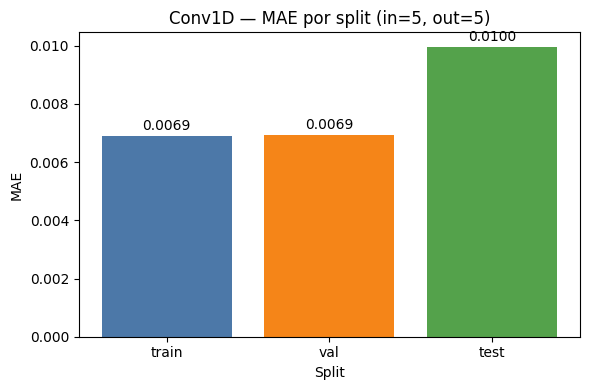

In [10]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_2.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 3

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_3 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_3.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_3 = model_3.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_3)

# Evaluación
result = {
    'train': eval_mae(model_3, X_tr, y_tr),
    'val':   eval_mae(model_3, X_v, y_v),
    'test':  eval_mae(model_3, X_ts, y_ts),
    'params': model_3.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_3.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out=30 | train=0.0054 val=0.0076 test=0.0110 ep=150


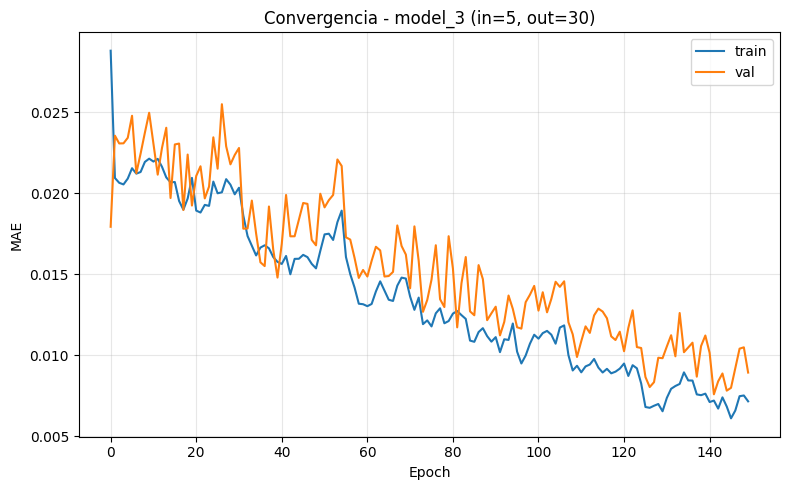

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(hist_3.history['loss'], label='train')
plt.plot(hist_3.history['val_loss'], label='val')

plt.title(f'Convergencia - model_3 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s     5     30 0.005411 0.007593 0.011033    5975 150


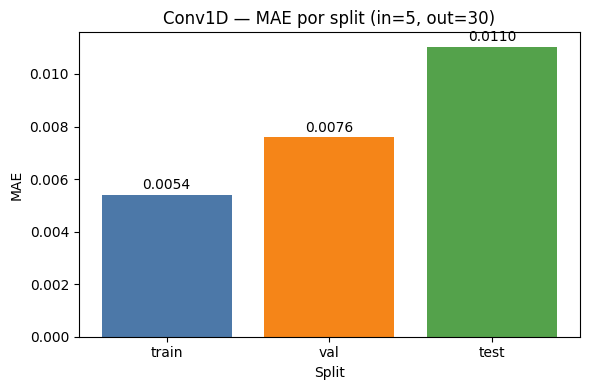

In [13]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_3.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 4

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_4 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_4.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_4 = model_4.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_4)

# Evaluación
result = {
    'train': eval_mae(model_4, X_tr, y_tr),
    'val':   eval_mae(model_4, X_v, y_v),
    'test':  eval_mae(model_4, X_ts, y_ts),
    'params': model_4.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_4.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out=90 | train=0.0095 val=0.0115 test=0.0196 ep=150


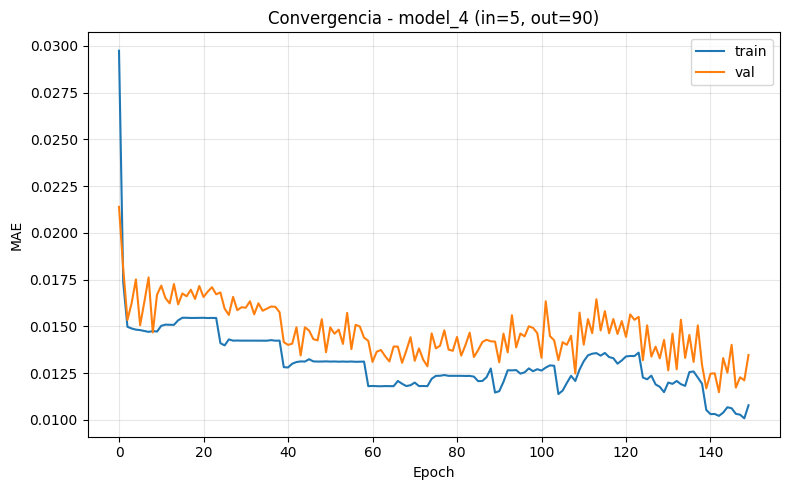

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(hist_4.history['loss'], label='train')
plt.plot(hist_4.history['val_loss'], label='val')

plt.title(f'Convergencia - model_4 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s     5     90 0.009472 0.011475 0.019643    5975 150


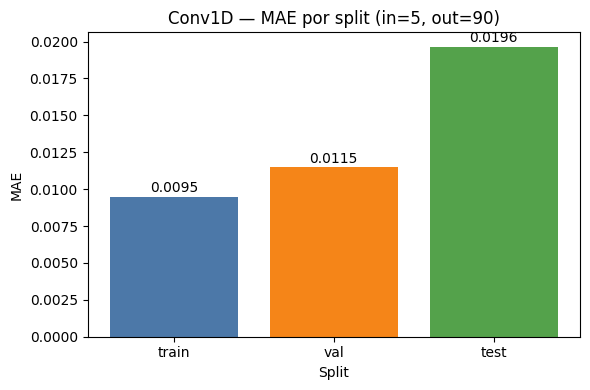

In [16]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_4.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 5

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_5 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_5.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_5 = model_5.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_5)

# Evaluación
result = {
    'train': eval_mae(model_5, X_tr, y_tr),
    'val':   eval_mae(model_5, X_v, y_v),
    'test':  eval_mae(model_5, X_ts, y_ts),
    'params': model_5.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_5.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out= 1 | train=0.0134 val=0.0125 test=0.0191 ep=150


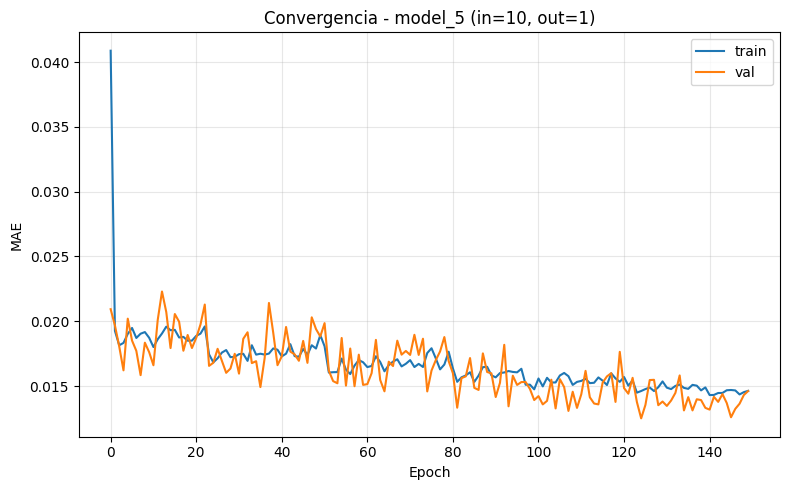

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(hist_5.history['loss'], label='train')
plt.plot(hist_5.history['val_loss'], label='val')

plt.title(f'Convergencia - model_5 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s    10      1 0.013356 0.012504 0.019146    5975 150


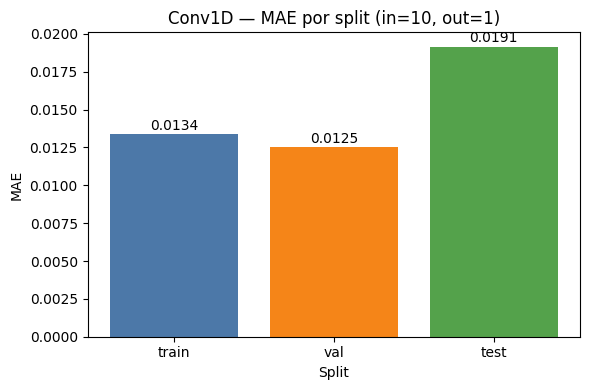

In [19]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_5.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 6

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_6 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_6.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_6 = model_6.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_6)

# Evaluación
result = {
    'train': eval_mae(model_6, X_tr, y_tr),
    'val':   eval_mae(model_6, X_v, y_v),
    'test':  eval_mae(model_6, X_ts, y_ts),
    'params': model_6.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_6.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out= 5 | train=0.0087 val=0.0114 test=0.0182 ep=150


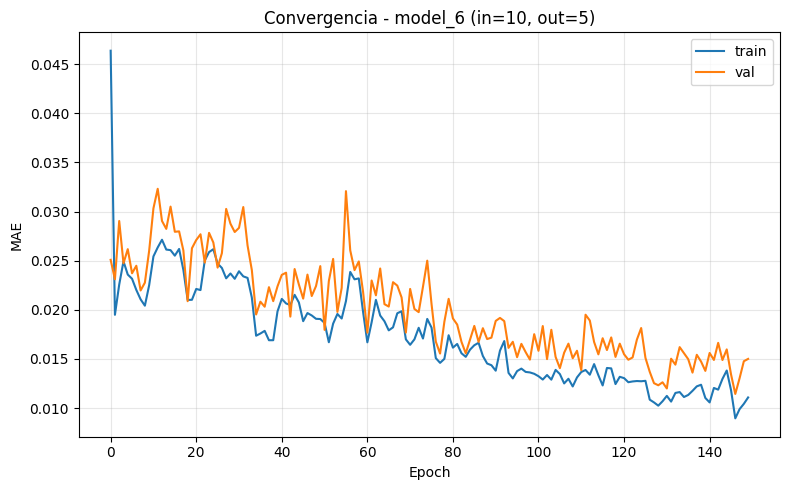

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(hist_6.history['loss'], label='train')
plt.plot(hist_6.history['val_loss'], label='val')

plt.title(f'Convergencia - model_6 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s    10      5 0.008721 0.011437 0.018223    5975 150


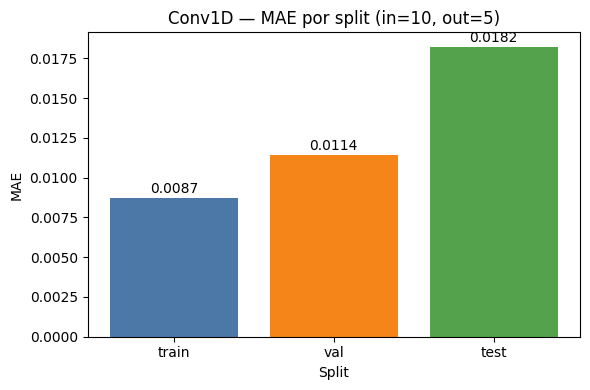

In [22]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_6.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 7

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_7 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_7.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_7 = model_7.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_7)

# Evaluación
result = {
    'train': eval_mae(model_7, X_tr, y_tr),
    'val':   eval_mae(model_7, X_v, y_v),
    'test':  eval_mae(model_7, X_ts, y_ts),
    'params': model_7.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_7.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out=30 | train=0.0153 val=0.0172 test=0.0230 ep=150


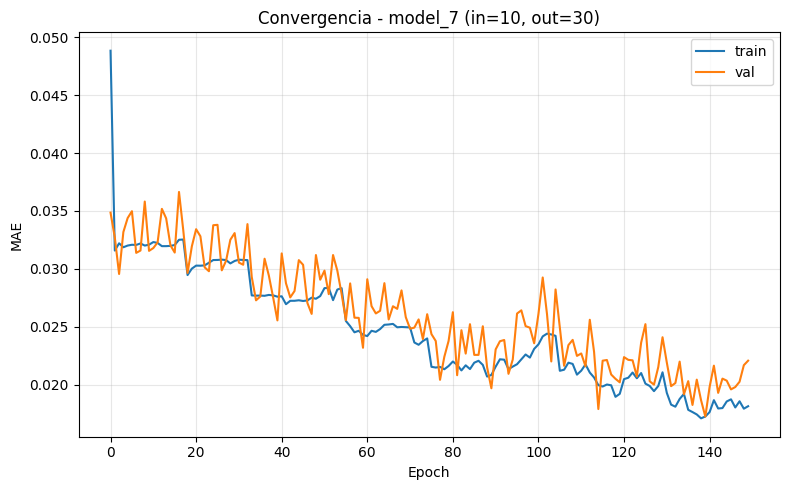

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(hist_7.history['loss'], label='train')
plt.plot(hist_7.history['val_loss'], label='val')

plt.title(f'Convergencia - model_7 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out   train      val     test  params  ep
conv_s    10     30 0.01525 0.017229 0.022986    5975 150


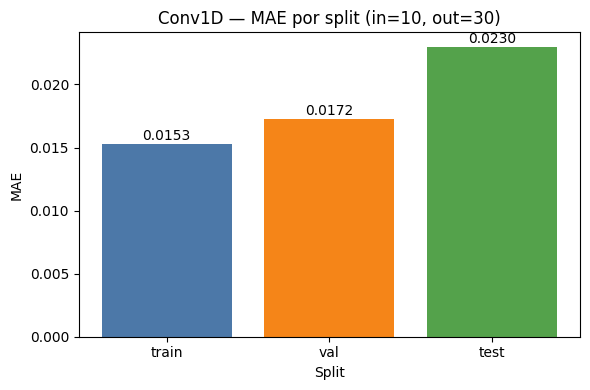

In [25]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_7.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 8

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_8 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_8.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_8 = model_8.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_8)

# Evaluación
result = {
    'train': eval_mae(model_8, X_tr, y_tr),
    'val':   eval_mae(model_8, X_v, y_v),
    'test':  eval_mae(model_8, X_ts, y_ts),
    'params': model_8.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_8.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out=90 | train=0.0130 val=0.0143 test=0.0187 ep=150


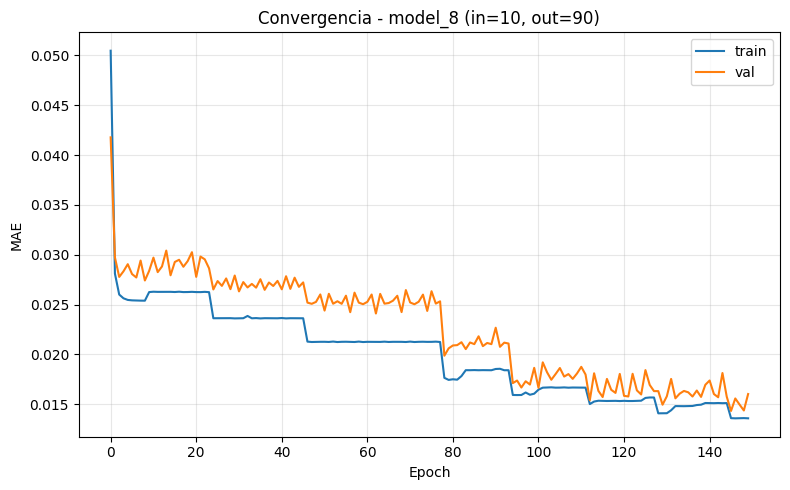

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(hist_8.history['loss'], label='train')
plt.plot(hist_8.history['val_loss'], label='val')

plt.title(f'Convergencia - model_8 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s    10     90 0.013036 0.014336 0.018724    5975 150


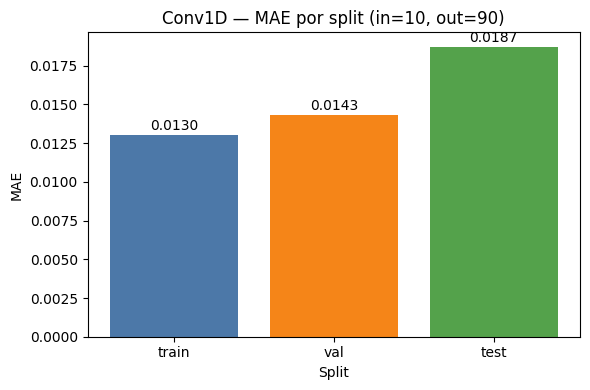

In [28]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_8.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 9

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 30  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_9 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_9.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_9 = model_9.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_9)

# Evaluación
result = {
    'train': eval_mae(model_9, X_tr, y_tr),
    'val':   eval_mae(model_9, X_v, y_v),
    'test':  eval_mae(model_9, X_ts, y_ts),
    'params': model_9.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_9.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=30 out= 1 | train=0.0137 val=0.0127 test=0.0172 ep=150


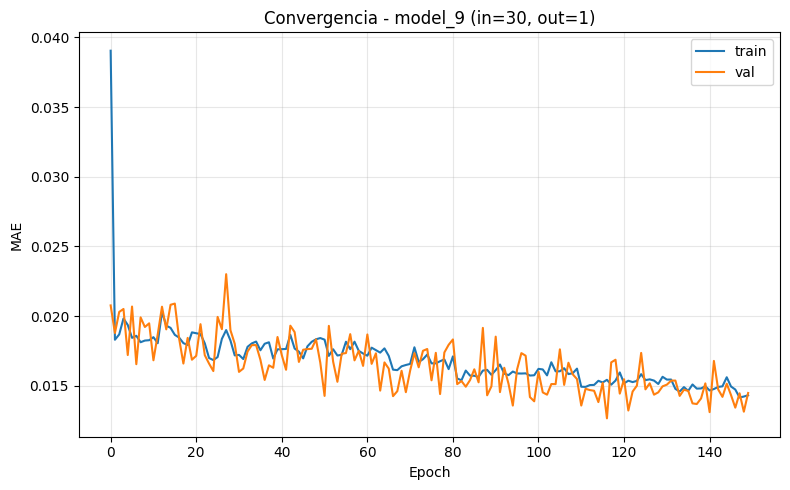

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(hist_9.history['loss'], label='train')
plt.plot(hist_9.history['val_loss'], label='val')

plt.title(f'Convergencia - model_9 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s    30      1 0.013677 0.012675 0.017208    5975 150


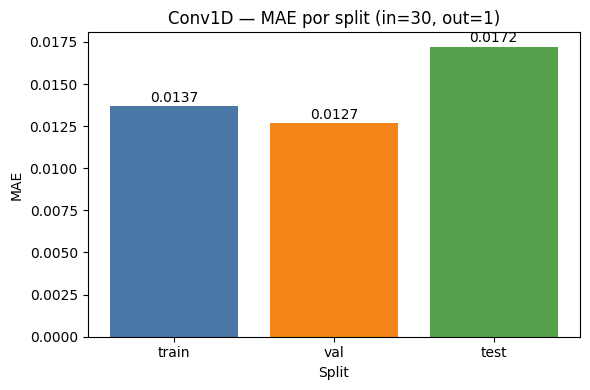

In [31]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_9.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 10 

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 30  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_10 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_10.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_10 = model_10.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_10)

# Evaluación
result = {
    'train': eval_mae(model_10, X_tr, y_tr),
    'val':   eval_mae(model_10, X_v, y_v),
    'test':  eval_mae(model_10, X_ts, y_ts),
    'params': model_10.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_10.history["loss"])}'
)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist_10.history['loss'], label='train')
plt.plot(hist_10.history['val_loss'], label='val')

plt.title(f'Convergencia - model_10 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_10.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 11 

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 30  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_11 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_11.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_11 = model_11.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_11)

# Evaluación
result = {
    'train': eval_mae(model_11, X_tr, y_tr),
    'val':   eval_mae(model_11, X_v, y_v),
    'test':  eval_mae(model_11, X_ts, y_ts),
    'params': model_11.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_11.history["loss"])}'
)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist_11.history['loss'], label='train')
plt.plot(hist_11.history['val_loss'], label='val')

plt.title(f'Convergencia - model_11 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_11.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 12

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 30  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_12 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_12.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_12 = model_12.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_12)

# Evaluación
result = {
    'train': eval_mae(model_12, X_tr, y_tr),
    'val':   eval_mae(model_12, X_v, y_v),
    'test':  eval_mae(model_12, X_ts, y_ts),
    'params': model_12.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_12.history["loss"])}'
)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist_12.history['loss'], label='train')
plt.plot(hist_12.history['val_loss'], label='val')

plt.title(f'Convergencia - model_12 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_12.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 13

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 90  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_13 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_13.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_13 = model_13.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_13)

# Evaluación
result = {
    'train': eval_mae(model_13, X_tr, y_tr),
    'val':   eval_mae(model_13, X_v, y_v),
    'test':  eval_mae(model_13, X_ts, y_ts),
    'params': model_13.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_13.history["loss"])}'
)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist_13.history['loss'], label='train')
plt.plot(hist_13.history['val_loss'], label='val')

plt.title(f'Convergencia - model_13 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_13.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 14

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 90  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_14 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_14.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_14 = model_14.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_14)

# Evaluación
result = {
    'train': eval_mae(model_14, X_tr, y_tr),
    'val':   eval_mae(model_14, X_v, y_v),
    'test':  eval_mae(model_14, X_ts, y_ts),
    'params': model_14.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_14.history["loss"])}'
)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist_14.history['loss'], label='train')
plt.plot(hist_14.history['val_loss'], label='val')

plt.title(f'Convergencia - model_14 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_14.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 15

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 90  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_15 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_15.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_15 = model_15.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_15)

# Evaluación
result = {
    'train': eval_mae(model_15, X_tr, y_tr),
    'val':   eval_mae(model_15, X_v, y_v),
    'test':  eval_mae(model_15, X_ts, y_ts),
    'params': model_15.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_15.history["loss"])}'
)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist_15.history['loss'], label='train')
plt.plot(hist_15.history['val_loss'], label='val')

plt.title(f'Convergencia - model_15 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_15.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 16

In [ ]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 90  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_16 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.001

model_16.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_16 = model_16.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_16)

# Evaluación
result = {
    'train': eval_mae(model_16, X_tr, y_tr),
    'val':   eval_mae(model_16, X_v, y_v),
    'test':  eval_mae(model_16, X_ts, y_ts),
    'params': model_16.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_16.history["loss"])}'
)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(hist_16.history['loss'], label='train')
plt.plot(hist_16.history['val_loss'], label='val')

plt.title(f'Convergencia - model_16 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_16.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()
